In [15]:
import logging
from pathlib import Path
from time import time
import pprint
import pandas as pd


import lightning as pl
import torch
import wandb

from lit_ecology_classifier.data.datamodule import DataModule
from lit_ecology_classifier.models.model import LitClassifier

In [3]:
# path for the classifcation path
base_path = Path("..")
output_path = base_path / "output" / "classification"
model_path = base_path / ".." / "models" / "zoo3.ckpt"
data_path = base_path / "data" /  "mini_dataset" / "polyarthra"

In [4]:

output_path.mkdir(parents=True, exist_ok=True)

In [6]:
model = LitClassifier.load_from_checkpoint(model_path, strict=False)

Model setup completed.
Model architecture:  beitv2
Number of classes:  38
Pretrained:  False
Total number of trainable parameters: %d 85791206
Total number of parameters: %d 85791206
Using standard cross entropy loss


/home/marco/miniconda3/envs/plank/lib/python3.9/site-packages/lightning/pytorch/core/saving.py:195: Found keys that are not in the model state dict but in the checkpoint: ['model.blocks.0.attn.relative_position_index', 'model.blocks.1.attn.relative_position_index', 'model.blocks.2.attn.relative_position_index', 'model.blocks.3.attn.relative_position_index', 'model.blocks.4.attn.relative_position_index', 'model.blocks.5.attn.relative_position_index', 'model.blocks.6.attn.relative_position_index', 'model.blocks.7.attn.relative_position_index', 'model.blocks.8.attn.relative_position_index', 'model.blocks.9.attn.relative_position_index', 'model.blocks.10.attn.relative_position_index', 'model.blocks.11.attn.relative_position_index']


In [7]:
model.hparams.batch_size = 32
model.hparams.TTA = False
model.hparams.outpath = output_path
model.hparams.datapath = data_path

In [8]:
print(model.hparams)

"TTA":              False
"balance_classes":  False
"batch_size":       32
"class_map":        {'aphanizomenon': 0, 'asplanchna': 1, 'asterionella': 2, 'bosmina': 3, 'ceratium': 4, 'chaoborus': 5, 'chlorophyte_colonial_reproduction': 6, 'chydorus': 7, 'collotheca': 8, 'conochilus': 9, 'copepod_skin': 10, 'cyclops': 11, 'daphnia': 12, 'daphnia_cucullata': 13, 'daphnia_skin': 14, 'diaphanosoma': 15, 'diatom_chain': 16, 'dinobryon': 17, 'eudiaptomus': 18, 'filament': 19, 'fish': 20, 'fragilaria': 21, 'hydra': 22, 'kellicottia': 23, 'keratella_cochlearis': 24, 'keratella_quadrata': 25, 'leptodora': 26, 'limnoraphis': 27, 'maybe_cyano': 28, 'nauplius': 29, 'paradileptus': 30, 'pennate_diatom': 31, 'polyarthra': 32, 'rotifer': 33, 'synchaeta': 34, 'trichocerca': 35, 'unknown': 36, 'uroglena': 37}
"datapath":         ../data/mini_dataset/polyarthra
"dataset":          zoo3
"loss":             cross_entropy
"lr":               0.0001
"lr_factor":        0.01
"main_param_path":  ./params/
"max_

In [9]:
data_module = DataModule(**model.hparams)
data_module.setup("predict")

In [10]:

model.load_datamodule(data_module)

In [11]:
trainer = pl.Trainer(
        # Set the number of GPUs to use for prediction if no_gpu is not set
        devices=  1, 
        strategy= "auto",
        enable_progress_bar = True,
        default_root_dir=output_path
    )
    

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/marco/miniconda3/envs/plank/lib/python3.9/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default


Predicting: |                                                                                                 …

/home/marco/miniconda3/envs/plank/lib/python3.9/site-packages/lightning/pytorch/loops/prediction_loop.py:257: predict returned None if it was on purpose, ignore this warning...


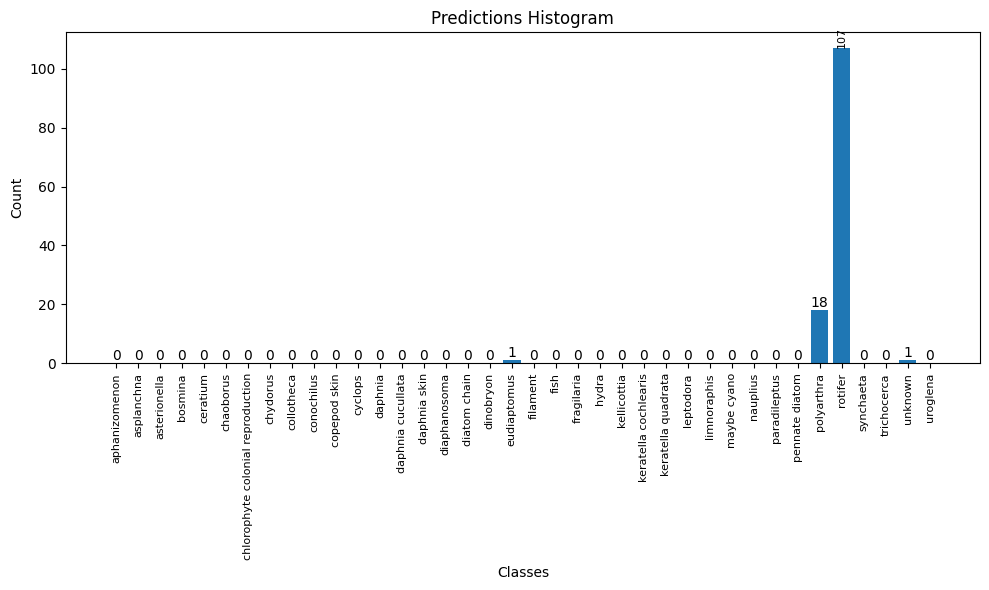

[None, None, None, None]

In [12]:
trainer.predict(model, datamodule=data_module)

In [16]:
test_report = pd.read_csv(test_report_file)
accuracy_value = format(float(test_report.iloc[0].item()), '.3f')
f1_value = format(float(test_report.iloc[2].item()), '.3f')

NameError: name 'test_report_file' is not defined